<a href="https://colab.research.google.com/github/RANJITHMUTHUSAMY005/Military_soldier/blob/main/Military_soldier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/Military.zip"
extract_path = "/content/drive/MyDrive/Military"
# create folder if not exists
os.makedirs(extract_path, exist_ok=True)

# unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [2]:
test_data="/content/drive/MyDrive/Military/military_object_dataset/test"
train_data="/content/drive/MyDrive/Military/military_object_dataset/train"
val_data="/content/drive/MyDrive/Military/military_object_dataset/val"

In [ ]:
test_data_label="/content/drive/MyDrive/Military/military_object_dataset/test/labels"
train_data_label="/content/drive/MyDrive/Military/military_object_dataset/train/labels"
val_data_label="/content/drive/MyDrive/Military/military_object_dataset/val/labels"

In [3]:
# importing required liberies
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
!pip install torch torchvision opencv-python matplotlib seaborn streamlit gdown



!pip install ultralytics
!pip install gdown
!pip install scikit-learn
!pip install py-yaml tqdm

!pip install torch torchvision torchaudio
!pip install ultralytics opencv-python matplotlib seaborn streamlit gdown scikit-learn py-yaml tqdm
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 142.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.4 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement py-yaml (from versions: none)
ERROR: No matching distribution found for py-yaml
ERROR: Could not find a version that satisfies the requirement py-yaml (from versions: none)
ERROR: No matching distribution found for py-yaml


In [10]:
# changeing the directory
import os
os.chdir("/content/drive/MyDrive/Military/military_object_dataset")

In [6]:
# visuvalising the images in train datasedt
img=Image.open("/content/drive/MyDrive/Military/military_object_dataset/test/images/000001.jpg")
img2=Image.open("/content/drive/MyDrive/Military/military_object_dataset/test/images/000002.jpg")

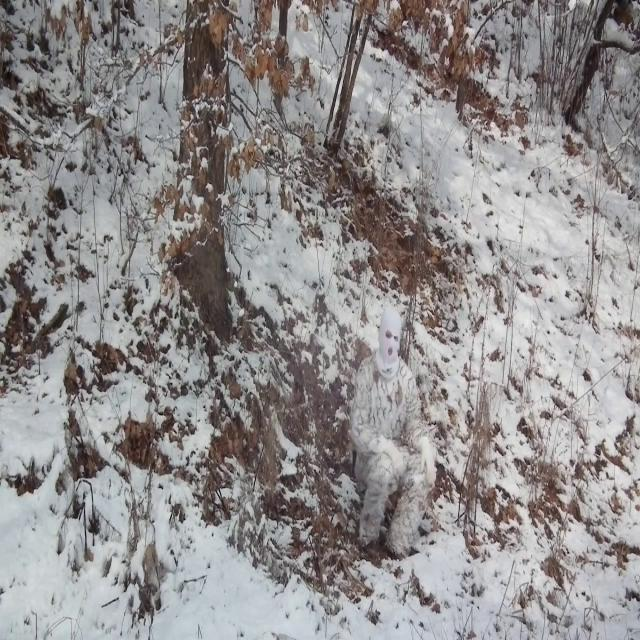

In [7]:
img

array([[[236, 237, 229],
        [236, 237, 229],
        [236, 237, 229],
        ...,
        [ 92,  98,  88],
        [ 92,  98,  88],
        [ 92,  98,  88]],

       [[236, 237, 229],
        [236, 237, 229],
        [236, 237, 229],
        ...,
        [ 92,  98,  88],
        [ 92,  98,  88],
        [ 92,  98,  88]],

       [[234, 235, 227],
        [234, 235, 227],
        [234, 235, 227],
        ...,
        [ 92,  98,  88],
        [ 92,  98,  88],
        [ 92,  98,  88]],

       ...,

       [[126, 127,  96],
        [131, 132, 101],
        [139, 140, 109],
        ...,
        [120, 118,  97],
        [161, 159, 138],
        [107, 105,  84]],

       [[123, 124,  93],
        [129, 130,  99],
        [138, 139, 108],
        ...,
        [124, 122, 101],
        [151, 149, 128],
        [104, 102,  81]],

       [[126, 127,  96],
        [130, 131, 100],
        [135, 136, 105],
        ...,
        [134, 132, 111],
        [142, 140, 119],
        [108, 106,  85]]], dtype=uint8)
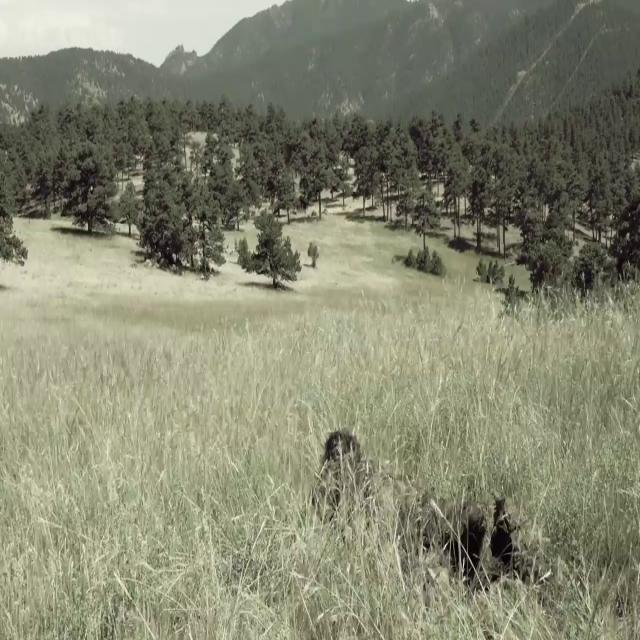

In [8]:
np.array(img2)

In [9]:
!pip install ultralytics --upgrade
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [12]:
import os

# Base dataset path
base_path = "/content/drive/MyDrive/Military/military_object_dataset"

# Folders to check
splits = ["train", "val", "test"]

# Extensions
image_extensions = (".jpg", ".jpeg", ".png")
label_extension = ".txt"

for split in splits:
    img_folder = os.path.join(base_path, split, "images")
    lbl_folder = os.path.join(base_path, split, "labels")

    # Count images
    images = [f for f in os.listdir(img_folder) if f.lower().endswith(image_extensions)]
    # Count labels
    labels = [f for f in os.listdir(lbl_folder) if f.lower().endswith(label_extension)]

    print(f"\n{split.upper()} SET")
    print(f"Images: {len(images)}")
    print(f"Labels: {len(labels)}")

    # Check mismatches
    img_names = {os.path.splitext(f)[0] for f in images}
    lbl_names = {os.path.splitext(f)[0] for f in labels}

    missing_labels = img_names - lbl_names
    missing_images = lbl_names - img_names

    if missing_labels:
        print(f"Missing labels for {len(missing_labels)} images")
    if missing_images:
        print(f"Missing images for {len(missing_images)} labels")
    if not missing_labels and not missing_images:
        print("All images have matching labels")


TRAIN SET
Images: 15536
Labels: 21978
Missing images for 6442 labels

VAL SET
Images: 2941
Labels: 2941
All images have matching labels

TEST SET
Images: 1396
Labels: 1396
All images have matching labels


In [13]:
yaml_text = """
path: /content/drive/MyDrive/Final_Military_project/military_object_dataset
train: /content/drive/MyDrive/Final_Military_project/military_object_dataset/train
val: /content/drive/MyDrive/Final_Military_project/military_object_dataset/val
test: /content/drive/MyDrive/Final_Military_project/military_object_dataset/test

nc: 12
names:
  0: camouflage_soldier
  1: weapon
  2: military_tank
  3: military_truck
  4: military_vehicle
  5: civilian
  6: soldier
  7: civilian_vehicle
  8: military_artillery
  9: trench
  10: military_aircraft
  11: military_warship
"""

with open("military_dataset.yaml", "w") as f:
    f.write(yaml_text)

In [15]:
import os
import shutil

original_dataset = "/content/drive/MyDrive/Military/military_object_dataset"
output_dataset = "/content/drive/MyDrive/small_dataset"

# Original to new class ID mapping
class_map = {1: 0, 3: 1, 4: 2, 8: 3, 11: 4}

def process_split(split):
    img_in = f"{original_dataset}/{split}/images"
    lbl_in = f"{original_dataset}/{split}/labels"
    img_out = f"{output_dataset}/{split}/images"
    lbl_out = f"{output_dataset}/{split}/labels"

    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    for file in os.listdir(lbl_in):
        label_path = os.path.join(lbl_in, file)
        new_lines = []

        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                cls = int(parts[0])
                if cls in class_map:
                    new_lines.append(f"{class_map[cls]} {' '.join(parts[1:])}\n")

        if new_lines:
            # Write new label file
            with open(os.path.join(lbl_out, file), "w") as f:
                f.writelines(new_lines)

            # Copy corresponding image
            img_file = file.replace(".txt", ".jpg")
            src_img = os.path.join(img_in, img_file)
            dst_img = os.path.join(img_out, img_file)
            if os.path.exists(src_img):
                shutil.copy(src_img, dst_img)

# Run on all splits
for split in ['train', 'val', 'test']:
    process_split(split)

In [16]:
yaml_text = """
path: /content/drive/MyDrive/small_dataset
train: /content/drive/MyDrive/small_dataset/train
val: /content/drive/MyDrive/small_dataset/val
test: /content/drive/MyDrive/small_dataset/test

names:
  0: weapon
  1: military_truck
  2: military_vehicle
  3: military_artillery
  4: military_warship
"""
with open("/content/drive/MyDrive/small_dataset/military_original_dataset.yaml", "w") as f:
    f.write(yaml_text)

In [18]:
from collections import Counter
import os

# Path to your original dataset labels
labels_path = "/content/drive/MyDrive/Military/military_object_dataset/train/labels"

# Initialize a counter for class frequencies
class_counts = Counter()

# List of class names (0-11)
class_names = [
    "camouflage_soldier", "weapon", "military_tank", "military_truck",
    "military_vehicle", "civilian", "soldier", "civilian_vehicle",
    "military_artillery", "trench", "military_aircraft", "military_warship"
]

# Loop through only .txt files
for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):
        file_path = os.path.join(labels_path, label_file)
        if os.path.isfile(file_path):
            with open(file_path, 'r') as f:
                for line in f:
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1

# Print class distribution
print("Class Distribution in Original Dataset (Train Split):")
for cid, count in sorted(class_counts.items()):
    print(f"{class_names[cid]}: {count}")

Class Distribution in Original Dataset (Train Split):
camouflage_soldier: 4477
weapon: 1210
military_tank: 17454
military_truck: 1245
military_vehicle: 1963
civilian: 52
soldier: 6502
civilian_vehicle: 519
military_artillery: 439
trench: 4
military_aircraft: 7337
military_warship: 2134


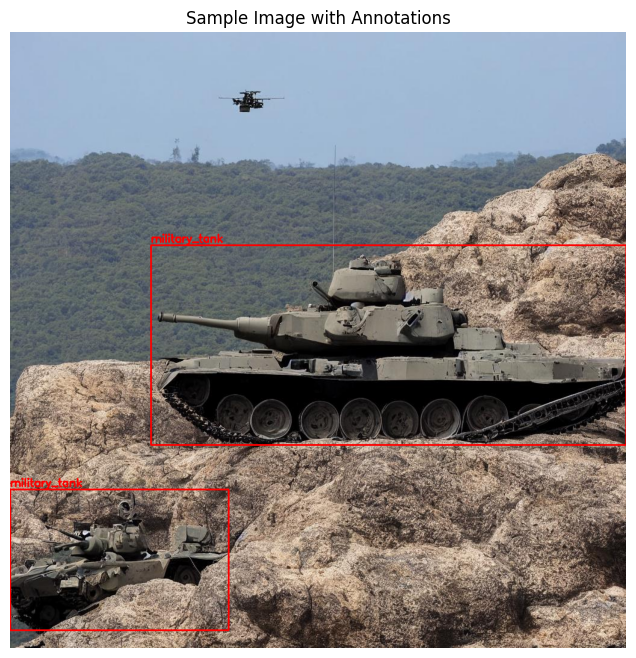

In [19]:
# Visualize Sample bounding boxes

import cv2
import matplotlib.pyplot as plt

img_dir = "/content/drive/MyDrive/Military/military_object_dataset/train/images"
label_dir = "/content/drive/MyDrive/Military/military_object_dataset/train/labels"

# Pick a sample image
img_file = os.listdir(img_dir)[0]
img_path = os.path.join(img_dir, img_file)
label_path = os.path.join(label_dir, img_file.replace(".jpg", ".txt"))

# Load image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# Draw bounding boxes
with open(label_path, "r") as f:
    for line in f:
        cls, x, y, bw, bh = map(float, line.strip().split())
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img, class_names[int(cls)], (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title("Sample Image with Annotations")
plt.show()

In [25]:
from ultralytics import YOLO

# Load pre-trained YOLOv8n model
model = YOLO("yolov8n.pt")

# Train the model
model.train(
    data="/content/drive/MyDrive/small_dataset/military_original_dataset.yaml",    # Path to dataset config
    epochs=50,                       # Number of epochs
    imgsz=640,                       # Input image size
    batch=8,                         # Batch size
    name="military_safety_yolov86",  # Experiment name
    patience=10,                     # Early stopping after 10 epochs with no improvement
    save_period=5                    # Save weights every 5 epochs
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/small_dataset/military_original_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=military_safety_yolov865, nbs=64, nms=False, opset=None, optimize=False, opti

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78c0b4700a70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [23]:
# Visualize evaluation results
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data="/content/drive/MyDrive/small_dataset/military_original_dataset.yaml",
    epochs=45,
    imgsz=640,
    batch=8,
    name="military_safety_yolov8",
    patience=5,        # stops early if no improvement
    save_period=5      # saves weights every 5 epochs
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/small_dataset/military_original_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=military_safety_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimi

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78bffae51280>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [1]:
!cp -r /content/runs/detect/military_safety_yolov8 /content/drive/MyDrive/Military/

cp: cannot stat '/content/runs/detect/military_safety_yolov8': No such file or directory


**Model Evaluation**

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Final_Military_project/military_safety_yolov8/weights/best.pt")

In [ ]:
# Evaluate on validation dataset
metrics = model.val(
    data="/content/drive/MyDrive/small_dataset/military_original_dataset.yaml"
)

# Print key metrics
print("Precision:", metrics.box.p)
print("Recall:", metrics.box.r)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

**# Visualize evaluation results**

In [ ]:
from IPython.display import Image, display
import os

# Path to the results image generated by YOLO
results_path = "/content/drive/MyDrive/Final_Military_project/military_safety_yolov8/results.png"

# Check if the file exists
if os.path.exists(results_path):
    display(Image(filename=results_path))
else:
    print("Results image not found. Make sure 'results.png' exists in the folder.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Metrics from YOLO training output
classes = ["weapon", "military_truck", "military_vehicle", "military_artillery", "military_warship"]
precision = [0.77593, 0.77593, 0.77593, 0.77593, 0]  # Replace with actual per-class precision if available
recall = [0.62339, 0.62339, 0.62339, 0.62339, 0]     # Replace with actual per-class recall if available
map_50 = 0.71179                                     # Overall mAP@0.5 from training

# Create DataFrame
df = pd.DataFrame({
    "Class": classes,
    "Precision": precision,
    "Recall": recall
})

# Plot bar chart with simple colors
plt.figure(figsize=(10, 6))
x = range(len(classes))
plt.bar(x, df["Precision"], width=0.4, label="Precision", color='skyblue', align='center')
plt.bar(x, df["Recall"], width=0.4, label="Recall", color='lightgreen', align='edge')
plt.xticks(x, classes, rotation=45)
plt.ylim(0, 1)
plt.title("Class-wise Precision and Recall")
plt.ylabel("Value")
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()

# Print summary
print("Overall mAP@0.5:", round(map_50, 3))

# Optional: Save as CSV
df.to_csv("/content/drive/MyDrive/Final_Military_project/model_performance_report.csv", index=False)